# 01 — Exploratory Data Analysis & Hypothesis Testing
**Project:** Regime-Aware Direction Classification for Gold & Silver  
**Data:** Gold (GC=F), Silver (SI=F), VIX, 10Y Treasury, USD Index | Feb 2010 – Mar 2026  
**Goal:** Understand the data — distributions, stationarity, macro relationships — before modelling.

## Setup & Data Load

In [3]:
from google.colab import files
files.upload()


Saving gold_silver_revised.csv to gold_silver_revised.csv


{'gold_silver_revised.csv': b'Date,gold,silver,vix,interest,usd_idx,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean\r\n03-02-2010,79.37000275,1111.400024,16.30999947,3.703000069,21.60000038,0.004546044,-0.005384076,0.004341228,0.011362473,0.001306222,-8.09E-05\r\n04-02-2010,79.91999817,1062.400024,15.34300041,3.609999895,26.07999992,0.006905614,-0.045089981,0.004521395,0.014987113,0.002022312,-0.003723115\r\n05-02-2010,80.44000244,1052.199951,14.82299995,3.546000004,26.11000061,0.006485484,-0.009647359,0.004594788,0.014458968,0.002721947,-0.003456027\r\n08-02-2010,80.30000305,1065.699951,15.07800007,3.592000008,26.51000023,-0.001741936,0.012748651,0.004577428,0.014895589,0.002662787,-0.002730514\r\n09-02-2010,79.86000061,1076.699951,15.43099976,3.632999897,26,-0.00549455,0.010268948,0.004564445,0.015091409,0.00180686,-0.001949852\r\n10-02-2010,80.02999878,1075.800049,15.30200005,3.694000006,25.39999962,0.00212644,-0.000836146,0.004226105,0.014777727,0.001701255,-0.000796224\r\n11-0

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('darkgrid')

# ── Load (works in Colab: upload gold_silver_revised.csv first)
df = pd.read_csv('gold_silver_revised.csv')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
df.head()

Shape      : (4056, 11)
Columns    : ['gold', 'silver', 'vix', 'interest', 'usd_idx', 'au_returns', 'ag_returns', 'au_vol', 'ag_vol', 'au_mean', 'ag_mean']


,gold,silver,vix,interest,usd_idx,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean
Date,,,,,,,,,,,
2010-02-03,79.370003,1111.400024,16.309999,3.703,21.600000,0.004546,-0.005384,0.004341,0.011362,0.001306,-0.000081
2010-02-04,79.919998,1062.400024,15.343000,3.610,26.080000,0.006906,-0.045090,0.004521,0.014987,0.002022,-0.003723
2010-02-05,80.440002,1052.199951,14.823000,3.546,26.110001,0.006485,-0.009647,0.004595,0.014459,0.002722,-0.003456
2010-02-08,80.300003,1065.699951,15.078000,3.592,26.510000,-0.001742,0.012749,0.004577,0.014896,0.002663,-0.002731
2010-02-09,79.860001,1076.699951,15.431000,3.633,26.000000,-0.005495,0.010269,0.004564,0.015091,0.001807,-0.001950


## 1. Price Series — Gold & Silver

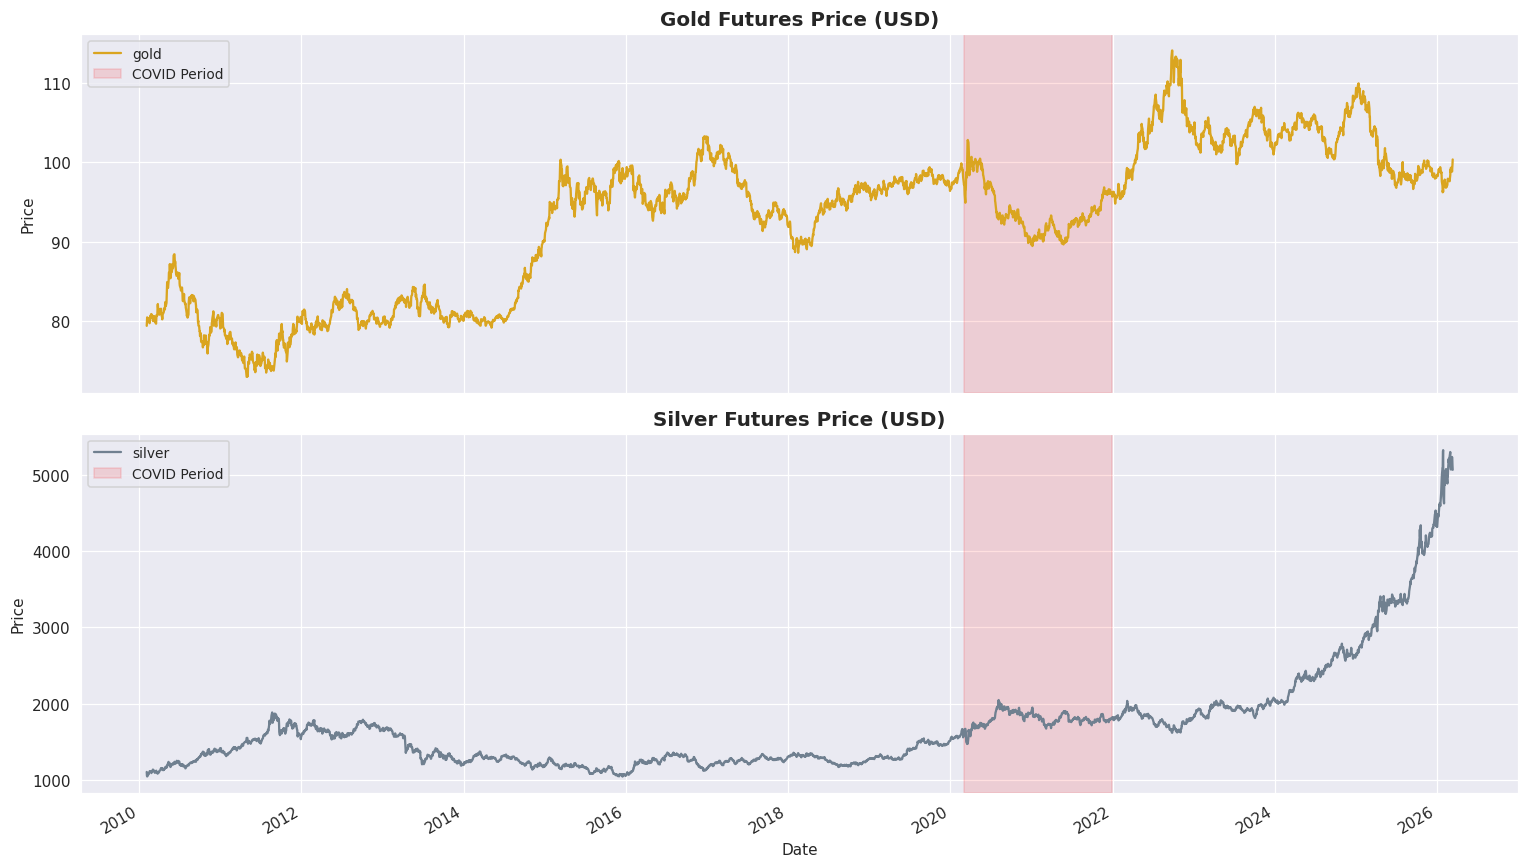

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

df['gold'].plot(ax=axes[0], color='goldenrod', linewidth=1.5)
axes[0].set_title('Gold Futures Price (USD)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price')

df['silver'].plot(ax=axes[1], color='slategray', linewidth=1.5)
axes[1].set_title('Silver Futures Price (USD)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price')

# Shade COVID period on both
for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.12, color='red', label='COVID Period')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## 2. Log Returns — Time Series & Distribution

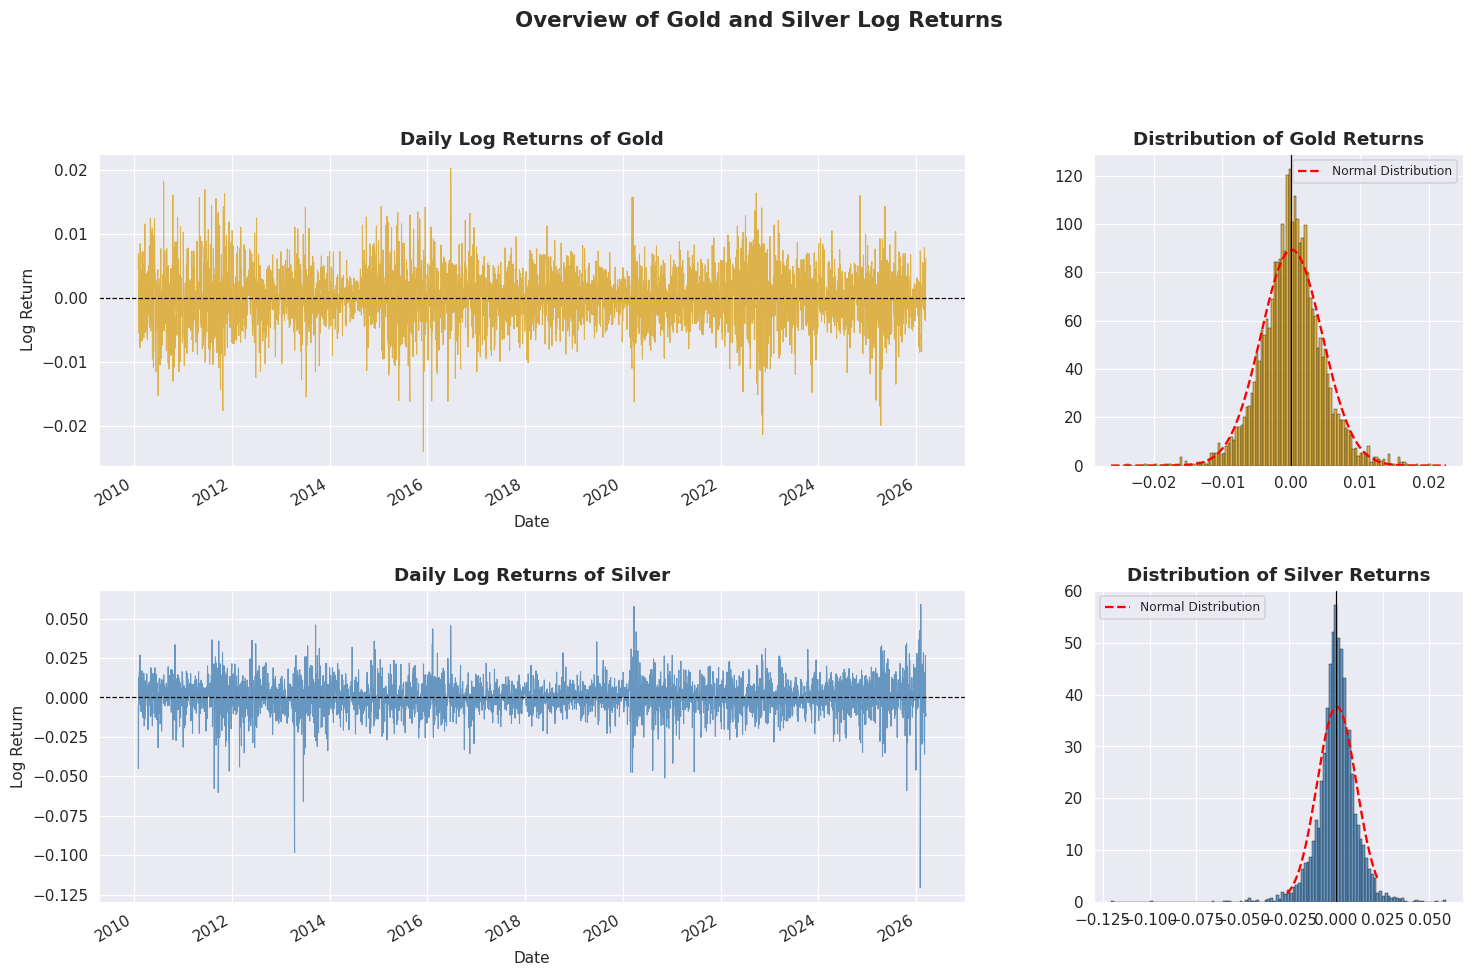

In [7]:
fig = plt.figure(figsize=(16, 10))
grid = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Time-series plot for gold log returns
gold_ax = fig.add_subplot(grid[0, :2])
df['au_returns'].plot(
    ax=gold_ax,
    color='goldenrod',
    linewidth=0.7,
    alpha=0.8
)
gold_ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
gold_ax.set_title('Daily Log Returns of Gold', fontweight='bold')
gold_ax.set_ylabel('Log Return')

# Histogram for gold returns
gold_hist_ax = fig.add_subplot(grid[0, 2])
gold_hist_ax.hist(
    df['au_returns'].dropna(),
    bins=120,
    color='goldenrod',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.8,
    density=True
)

x_min, x_max = gold_hist_ax.get_xlim()
x_vals = np.linspace(x_min, x_max, 200)

gold_mean = df['au_returns'].mean()
gold_std  = df['au_returns'].std()

gold_hist_ax.plot(
    x_vals,
    stats.norm.pdf(x_vals, gold_mean, gold_std),
    'r--',
    linewidth=1.5,
    label='Normal Distribution'
)

gold_hist_ax.axvline(0, color='black', linewidth=0.8)
gold_hist_ax.set_title('Distribution of Gold Returns', fontweight='bold')
gold_hist_ax.legend(fontsize=8)

# Time-series plot for silver log returns
silver_ax = fig.add_subplot(grid[1, :2])
df['ag_returns'].plot(
    ax=silver_ax,
    color='steelblue',
    linewidth=0.7,
    alpha=0.8
)

silver_ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
silver_ax.set_title('Daily Log Returns of Silver', fontweight='bold')
silver_ax.set_ylabel('Log Return')

# Histogram for silver returns
silver_hist_ax = fig.add_subplot(grid[1, 2])
silver_hist_ax.hist(
    df['ag_returns'].dropna(),
    bins=120,
    color='steelblue',
    edgecolor='black',
    linewidth=0.3,
    alpha=0.8,
    density=True
)

silver_mean = df['ag_returns'].mean()
silver_std  = df['ag_returns'].std()

silver_hist_ax.plot(
    x_vals,
    stats.norm.pdf(x_vals, silver_mean, silver_std),
    'r--',
    linewidth=1.5,
    label='Normal Distribution'
)

silver_hist_ax.axvline(0, color='black', linewidth=0.8)
silver_hist_ax.set_title('Distribution of Silver Returns', fontweight='bold')
silver_hist_ax.legend(fontsize=8)

plt.suptitle(
    'Overview of Gold and Silver Log Returns',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.show()

## 3. Descriptive Statistics

In [8]:
desc = df[['au_returns', 'ag_returns']].describe().T
desc['skewness'] = df[['au_returns', 'ag_returns']].skew()
desc['kurtosis'] = df[['au_returns', 'ag_returns']].kurtosis()
desc['pct_positive'] = (df[['au_returns', 'ag_returns']] > 0).mean()

desc.index = ['Gold Returns', 'Silver Returns']
print("=== Descriptive Statistics ===")
print(desc.round(6).to_string())

print("\n=== Interpretation ===")
print(f"Gold  | Kurtosis={desc.loc['Gold Returns','kurtosis']:.2f}  → fat tails (leptokurtic)")
print(f"Silver| Kurtosis={desc.loc['Silver Returns','kurtosis']:.2f} → fatter tails")
print(f"Gold  | % Positive days = {desc.loc['Gold Returns','pct_positive']:.1%}")
print(f"Silver| % Positive days = {desc.loc['Silver Returns','pct_positive']:.1%}")

=== Descriptive Statistics ===
                 count      mean       std       min       25%       50%       75%       max  skewness  kurtosis  pct_positive
Gold Returns    4056.0  0.000059  0.004465 -0.023988 -0.002522  0.000098  0.002599  0.020320 -0.037502  1.531382      0.501726
Silver Returns  4056.0  0.000372  0.010591 -0.120657 -0.004555  0.000450  0.005957  0.059054 -0.839080  9.139543      0.528107

=== Interpretation ===
Gold  | Kurtosis=1.53  → fat tails (leptokurtic)
Silver| Kurtosis=9.14 → fatter tails
Gold  | % Positive days = 50.2%
Silver| % Positive days = 52.8%


## 4. Stationarity Tests (ADF + KPSS)

In [9]:
def stationarity_report(series, name):
    s = series.dropna()
    adf_stat, adf_p, *_, adf_crit = adfuller(s)
    kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')

    verdict = "STATIONARY" if (adf_p < 0.05 and kpss_p > 0.05) else               " CONFLICTING" if (adf_p < 0.05 or kpss_p > 0.05) else               " NON-STATIONARY"

    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"{'─'*52}")
    print(f"  ADF  | stat={adf_stat:8.4f} | p={adf_p:.4f} | {'Stationary' if adf_p<0.05 else 'Non-Stationary'}")
    print(f"  KPSS | stat={kpss_stat:8.4f} | p={kpss_p:.4f} | {'Stationary' if kpss_p>0.05 else 'Non-Stationary'}")
    print(f"  → {verdict}")

print("=== PRICES (Raw) ===")
stationarity_report(df['gold'], 'Gold Price')
stationarity_report(df['silver'], 'Silver Price')

print("\n=== LOG RETURNS ===")
stationarity_report(df['au_returns'], 'Gold Log Returns')
stationarity_report(df['ag_returns'], 'Silver Log Returns')

=== PRICES (Raw) ===

────────────────────────────────────────────────────
  Gold Price
────────────────────────────────────────────────────
  ADF  | stat= -1.6889 | p=0.4369 | Non-Stationary
  KPSS | stat=  7.5743 | p=0.0100 | Non-Stationary
  →  NON-STATIONARY

────────────────────────────────────────────────────
  Silver Price
────────────────────────────────────────────────────
  ADF  | stat=  5.1325 | p=1.0000 | Non-Stationary
  KPSS | stat=  5.0871 | p=0.0100 | Non-Stationary
  →  NON-STATIONARY

=== LOG RETURNS ===

────────────────────────────────────────────────────
  Gold Log Returns
────────────────────────────────────────────────────
  ADF  | stat=-62.7767 | p=0.0000 | Stationary
  KPSS | stat=  0.0610 | p=0.1000 | Stationary
  → STATIONARY

────────────────────────────────────────────────────
  Silver Log Returns
────────────────────────────────────────────────────
  ADF  | stat=-65.9212 | p=0.0000 | Stationary
  KPSS | stat=  0.6384 | p=0.0191 | Non-Stationary
  →  CONFLI

## 5. ACF / PACF — Returns & Squared Returns (Volatility Clustering Check)

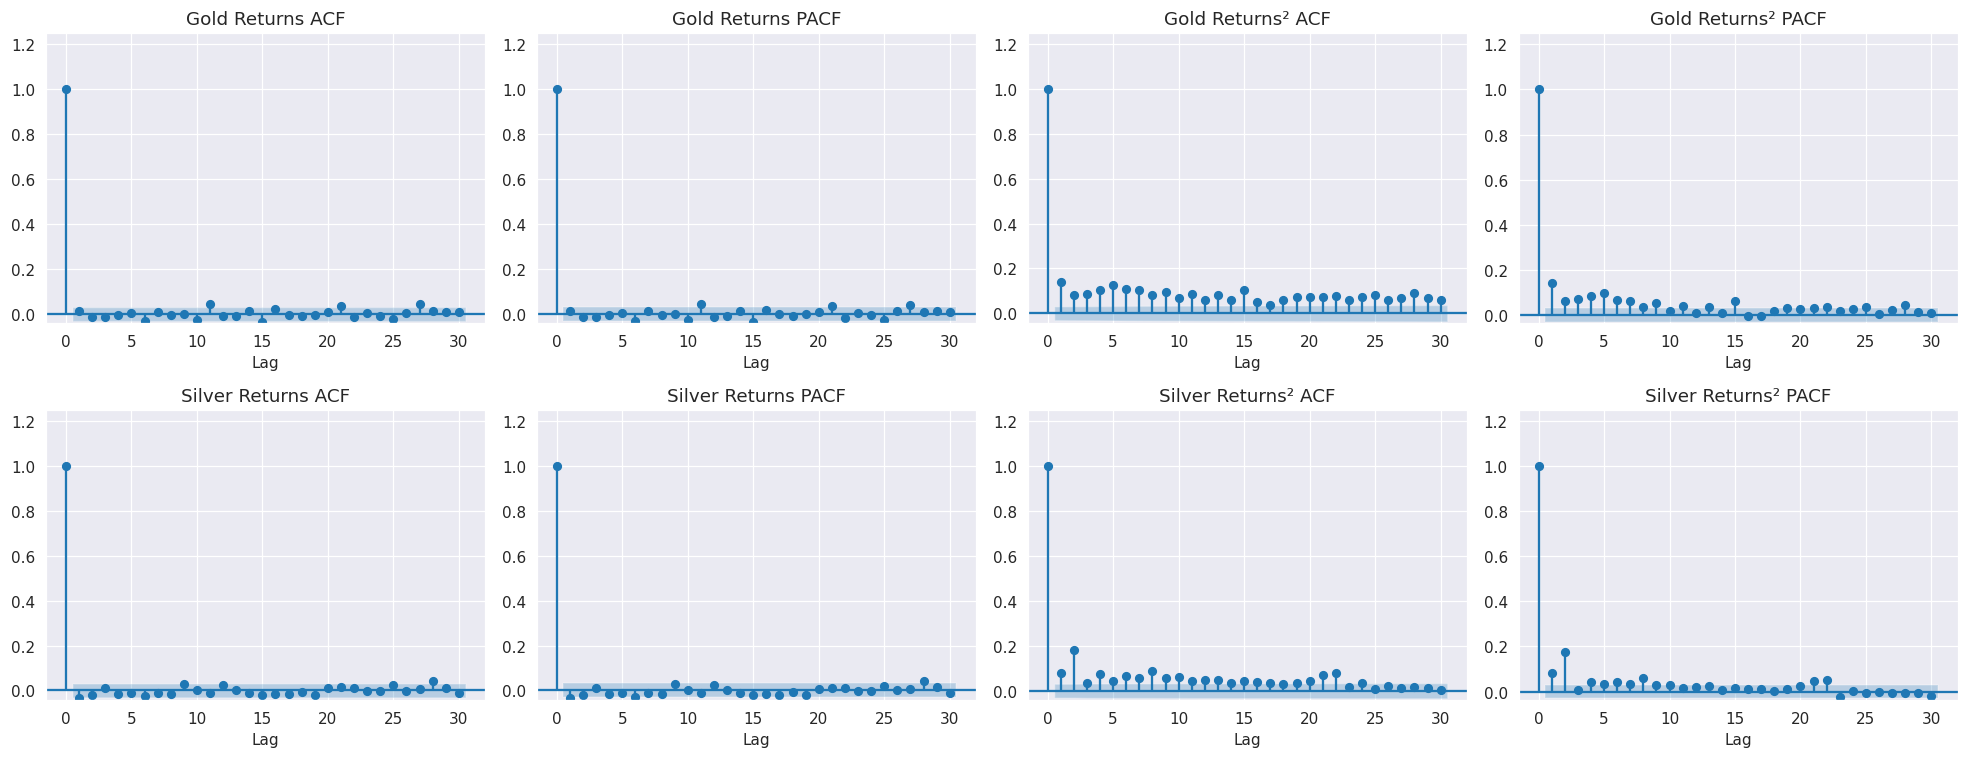

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
titles = ['Gold Returns ACF', 'Gold Returns PACF',
          'Gold Returns² ACF', 'Gold Returns² PACF',
          'Silver Returns ACF', 'Silver Returns PACF',
          'Silver Returns² ACF', 'Silver Returns² PACF']

au_ret = df['au_returns'].dropna()
ag_ret = df['ag_returns'].dropna()
series = [au_ret, au_ret, au_ret**2, au_ret**2,
          ag_ret, ag_ret, ag_ret**2, ag_ret**2]
funcs  = [plot_acf, plot_pacf, plot_acf, plot_pacf] * 2

for ax, fn, s, t in zip(axes.flatten(), funcs, series, titles):
    fn(s, lags=30, ax=ax, title=t, auto_ylims=True)
    ax.set_xlabel('Lag')

plt.tight_layout()
plt.show()

## 6. Macro Features — VIX, Interest, USD Index

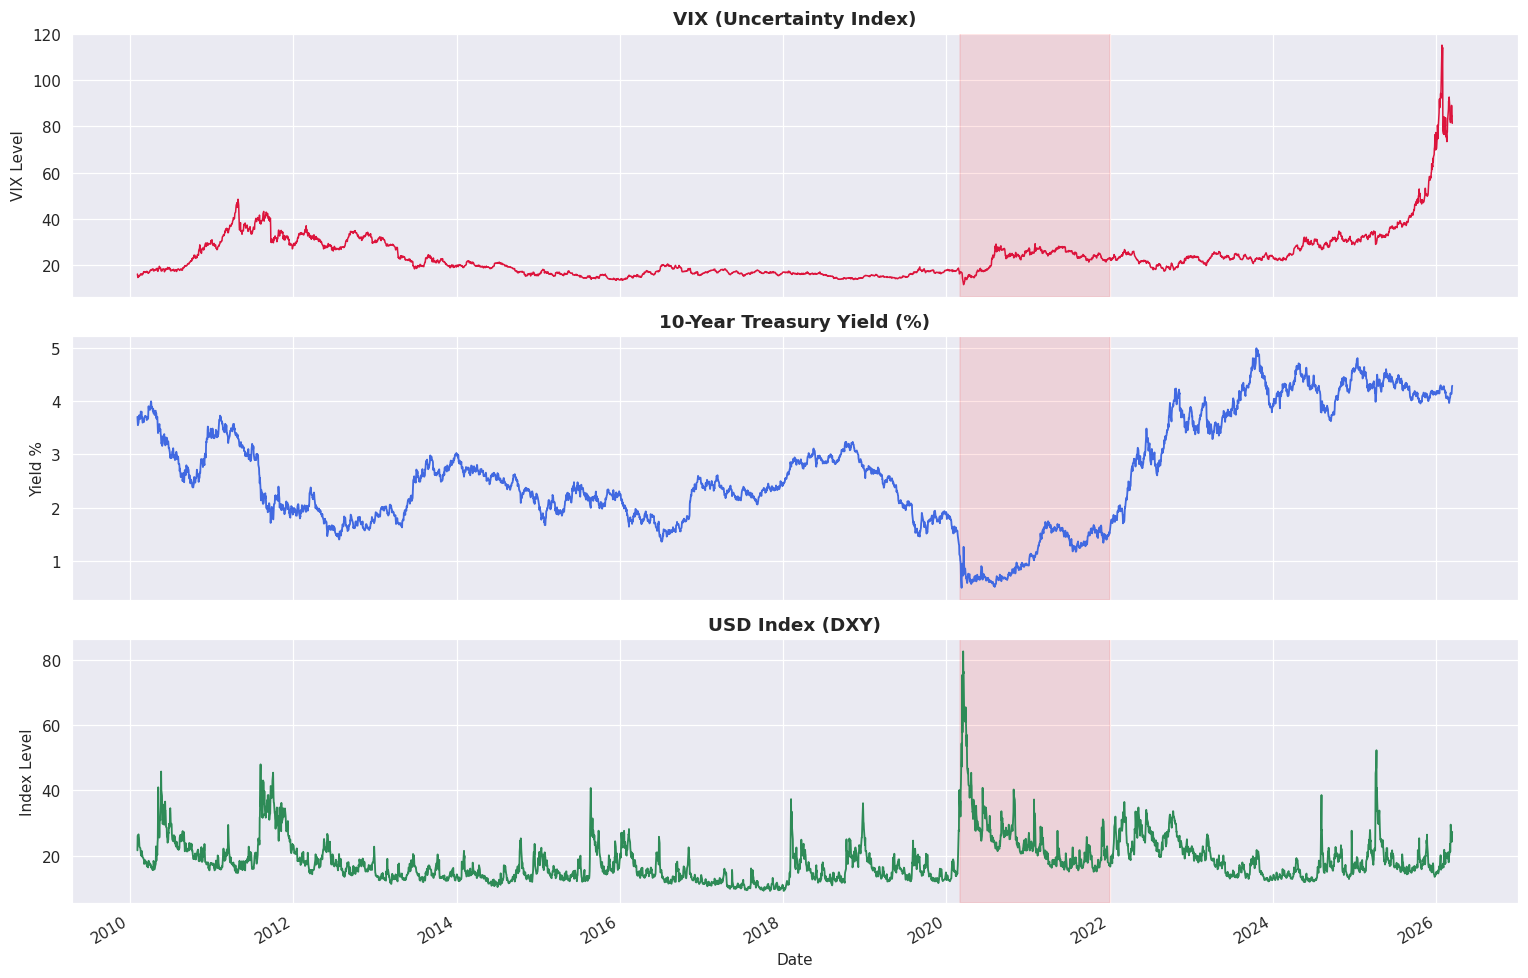

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

df['vix'].plot(ax=axes[0], color='crimson', linewidth=1, label='VIX')
axes[0].set_title('VIX (Uncertainty Index)', fontweight='bold')
axes[0].set_ylabel('VIX Level')

df['interest'].plot(ax=axes[1], color='royalblue', linewidth=1.2)
axes[1].set_title('10-Year Treasury Yield (%)', fontweight='bold')
axes[1].set_ylabel('Yield %')

df['usd_idx'].plot(ax=axes[2], color='seagreen', linewidth=1.2)
axes[2].set_title('USD Index (DXY)', fontweight='bold')
axes[2].set_ylabel('Index Level')

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
               alpha=0.1, color='red', label='COVID')

plt.tight_layout()
plt.show()

## 7. Correlation Matrix

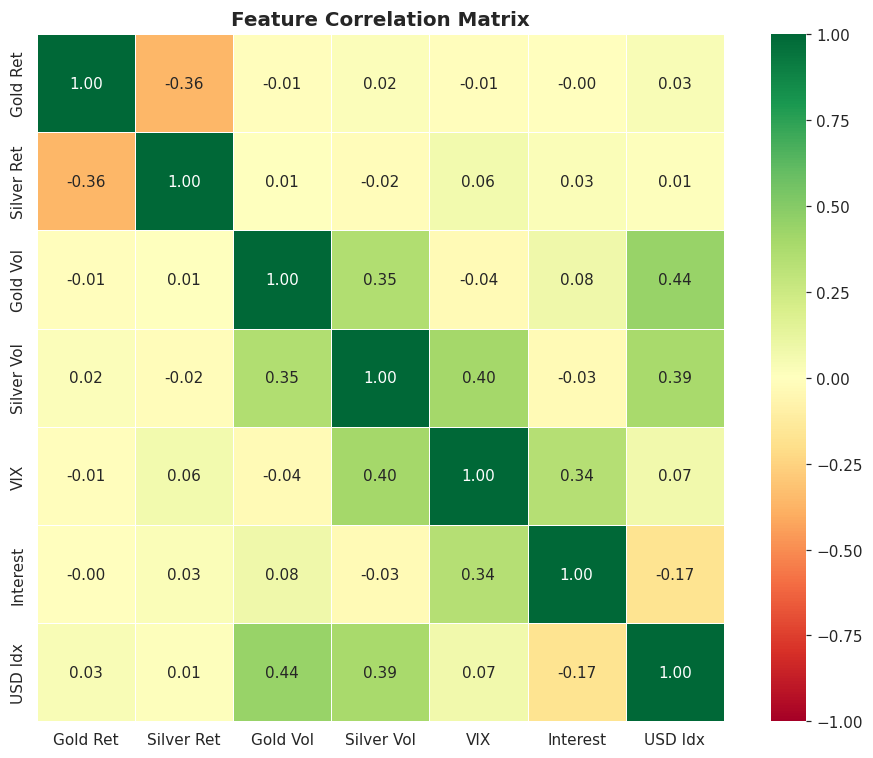

In [13]:
cols = ['au_returns', 'ag_returns', 'au_vol', 'ag_vol',
        'vix', 'interest', 'usd_idx']
labels = ['Gold Ret', 'Silver Ret', 'Gold Vol', 'Silver Vol',
          'VIX', 'Interest', 'USD Idx']

corr = df[cols].corr()
corr.index = labels
corr.columns = labels

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            mask=False, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Rolling Correlation — Gold vs Silver

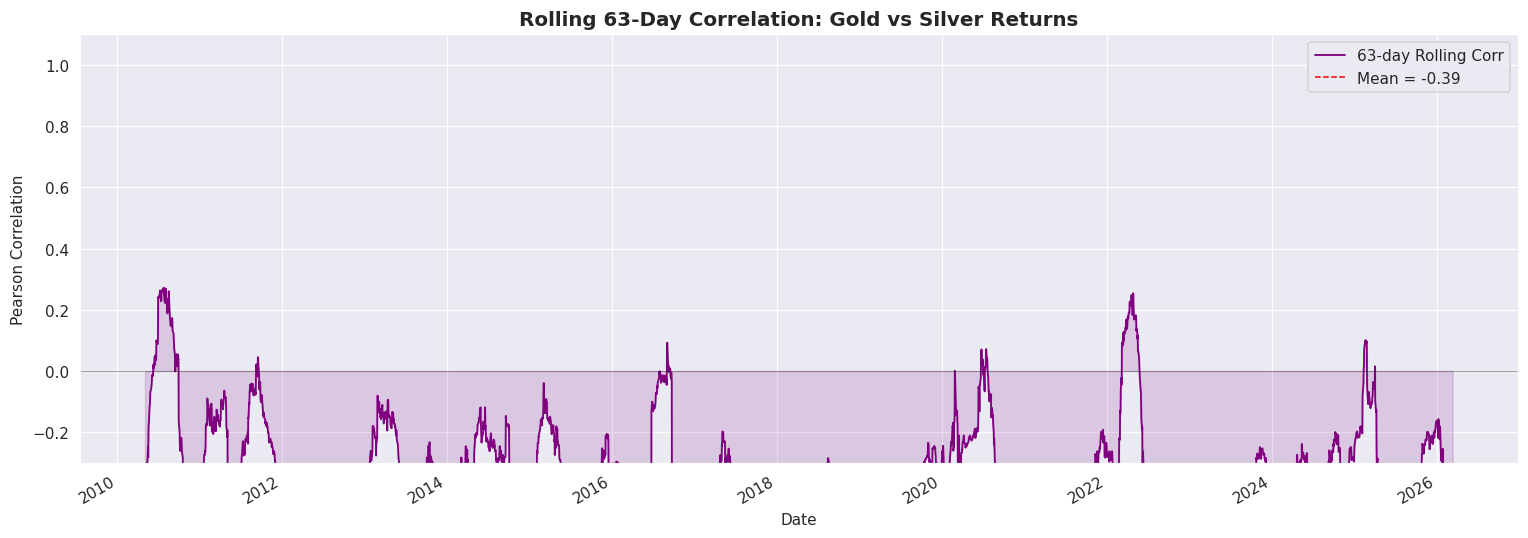

Mean correlation: -0.391
Min:  -0.774  |  Max: 0.272


In [14]:
roll_corr = df['au_returns'].rolling(63).corr(df['ag_returns'])  # ~3 months

plt.figure(figsize=(14, 5))
roll_corr.plot(color='purple', linewidth=1.2, label='63-day Rolling Corr')
plt.axhline(roll_corr.mean(), color='red', linestyle='--', linewidth=1,
            label=f'Mean = {roll_corr.mean():.2f}')
plt.axhline(0, color='black', linewidth=0.6, alpha=0.4)
plt.fill_between(roll_corr.index, roll_corr, alpha=0.15, color='purple')
plt.title('Rolling 63-Day Correlation: Gold vs Silver Returns', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.ylim(-0.3, 1.1)
plt.legend()
plt.tight_layout()
plt.show()
print(f"Mean correlation: {roll_corr.mean():.3f}")
print(f"Min:  {roll_corr.min():.3f}  |  Max: {roll_corr.max():.3f}")

## 9. Year-wise Summary Statistics

      Gold_MeanRet  Silver_MeanRet  Gold_Vol  Silver_Vol  Gold_PctUp  Silver_PctUp
year                                                                              
2010       0.00000         0.00104   0.00557     0.00990     0.50216       0.60173
2011       0.00006         0.00038   0.00578     0.01334     0.45238       0.56746
2012      -0.00002         0.00027   0.00404     0.01028     0.51600       0.52000
2013       0.00001        -0.00132   0.00406     0.01417     0.49206       0.45635
2014       0.00048        -0.00006   0.00328     0.00894     0.53968       0.47222
2015       0.00035        -0.00044   0.00587     0.00928     0.53968       0.44444
2016       0.00015         0.00032   0.00473     0.01017     0.49012       0.48221
2017      -0.00042         0.00051   0.00374     0.00654     0.48606       0.54980
2018       0.00017        -0.00009   0.00377     0.00662     0.50199       0.47809
2019       0.00001         0.00069   0.00285     0.00725     0.48810       0.54365
2020

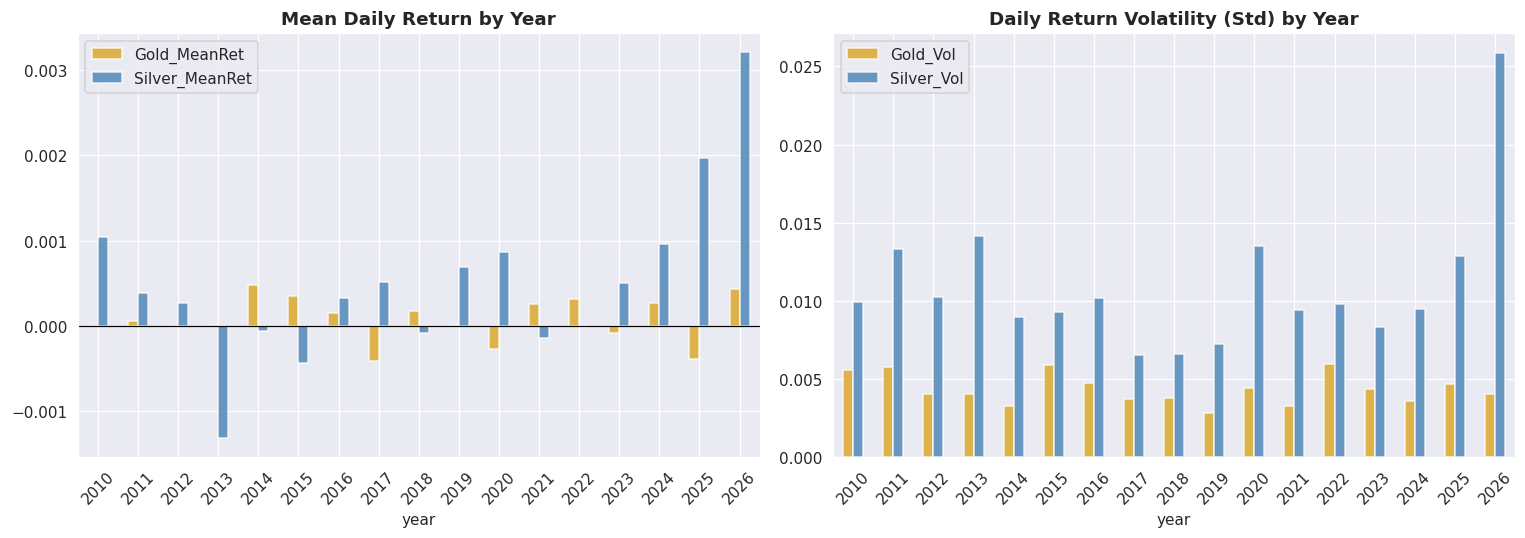

In [15]:
df['year'] = df.index.year
yw = df.groupby('year').agg(
    Gold_MeanRet  = ('au_returns', 'mean'),
    Silver_MeanRet= ('ag_returns', 'mean'),
    Gold_Vol      = ('au_returns', 'std'),
    Silver_Vol    = ('ag_returns', 'std'),
    Gold_PctUp    = ('au_returns', lambda x: (x > 0).mean()),
    Silver_PctUp  = ('ag_returns', lambda x: (x > 0).mean()),
).round(5)

print(yw.to_string())

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yw[['Gold_MeanRet','Silver_MeanRet']].plot(kind='bar', ax=axes[0],
    color=['goldenrod','steelblue'], alpha=0.8)
axes[0].set_title('Mean Daily Return by Year', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xticklabels(yw.index, rotation=45)

yw[['Gold_Vol','Silver_Vol']].plot(kind='bar', ax=axes[1],
    color=['goldenrod','steelblue'], alpha=0.8)
axes[1].set_title('Daily Return Volatility (Std) by Year', fontweight='bold')
axes[1].set_xticklabels(yw.index, rotation=45)

plt.tight_layout()
plt.show()
df.drop(columns=['year'], inplace=True)

## Summary
- **Raw prices** are **non-stationary** (confirmed by ADF/KPSS) — we model log returns, not prices
- **Log returns** are **stationary** — safe for modelling
- **Squared returns** show significant autocorrelation → **ARCH effects exist → GARCH justified** (next notebook)
- Gold and Silver are highly correlated (~0.6–0.7) but diverge during stress periods
- Target is nearly **50/50 balanced** (up vs down days) — no class imbalance issue
- COVID period (Mar 2020 – Dec 2021) shows clearly elevated volatility in all series

**→ Next: Notebook 02 — GARCH Volatility Modelling & Regime Definition**